In [9]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
from pandas.core.arrays import timedeltas
from sklearn.preprocessing import StandardScaler
import numpy as np


In [10]:

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

df = pd.read_csv(path+'/marketing_campaign.csv', sep='\t')

In [11]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


# Data Feature Inspection

## Data Inspecting

--- 상관계수 행렬 ---
                           ID  Year_Birth    Income   Kidhome  Teenhome  \
ID                   1.000000    0.000028  0.013095  0.002406 -0.002580   
Year_Birth           0.000028    1.000000 -0.161791  0.230176 -0.352111   
Income               0.013095   -0.161791  1.000000 -0.428669  0.019133   
Kidhome              0.002406    0.230176 -0.428669  1.000000 -0.036133   
Teenhome            -0.002580   -0.352111  0.019133 -0.036133  1.000000   
Recency             -0.046524   -0.019871 -0.003970  0.008827  0.016198   
MntWines            -0.022878   -0.157773  0.578650 -0.496297  0.004846   
MntFruits            0.004600   -0.017917  0.430842 -0.372581 -0.176764   
MntMeatProducts     -0.004437   -0.030872  0.584633 -0.437129 -0.261160   
MntFishProducts     -0.024475   -0.041625  0.438871 -0.387644 -0.204187   
MntSweetProducts    -0.007642   -0.018133  0.440744 -0.370673 -0.162475   
MntGoldProds        -0.013438   -0.061818  0.325916 -0.349595 -0.021725   
NumDealsP

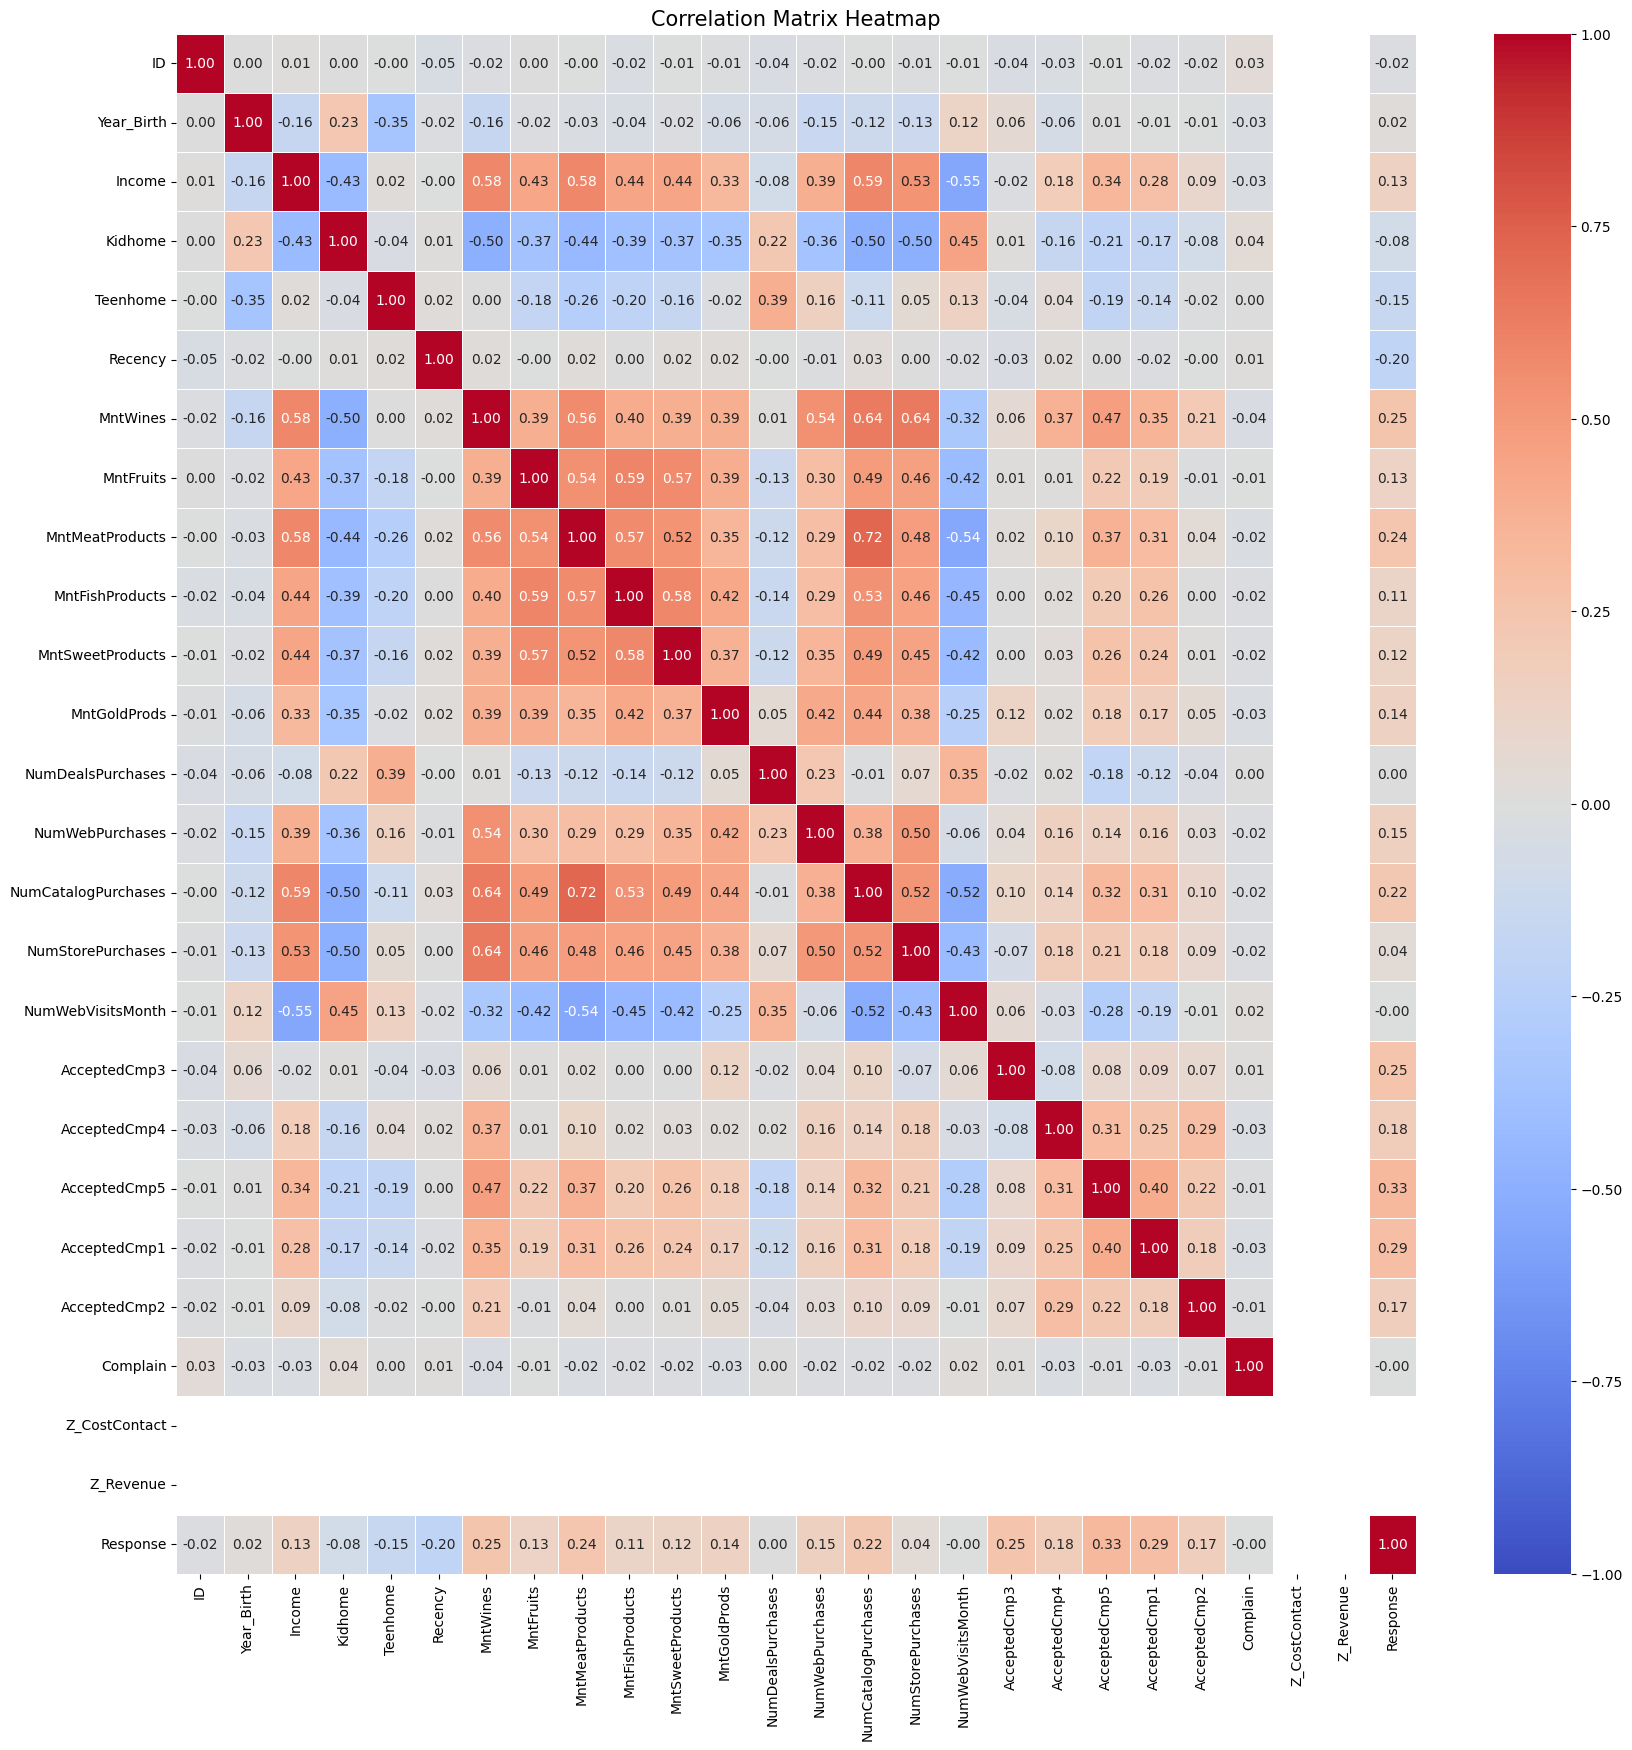

In [12]:
corr_matrix = df.corr(method='pearson', numeric_only=True)
print("--- 상관계수 행렬 ---")
print(corr_matrix)

# 3. 히트맵(Heatmap) 시각화
plt.figure(figsize=(20, 20))

# annot=True: 네모 칸 안에 숫자를 표시
# cmap='coolwarm': 양의 상관관계는 빨간색, 음의 상관관계는 파란색으로 표시
# vmin=-1, vmax=1: 색상 범위를 -1에서 1로 고정
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",       # 숫자가 겹치지 않게 소수점 둘째 자리까지만 표시
            cmap='coolwarm', # 파란색(음수) ~ 하얀색(0) ~ 빨간색(양수)
            vmin=-1,         # 최솟값은 무조건 -1
            vmax=1,          # 최댓값은 무조건 1
            linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=15)
plt.show()

## Feature Engineering
Let data collect date is 2014-08-01
1. Year_Birth to Age
2. Dt_Customer to Enrollment_days
3. Mnt* to TotalSpent
4. Accepted* to TotalCmp

In [13]:
df_eng = df.copy(deep=True)

In [14]:
df_eng['Age'] = 2014-df['Year_Birth']

(array([ 61., 240., 394., 540., 350., 336., 260.,  54.,   2.,   0.,   0.,
          0.,   0.,   1.,   2.]),
 array([ 18.        ,  24.86666667,  31.73333333,  38.6       ,
         45.46666667,  52.33333333,  59.2       ,  66.06666667,
         72.93333333,  79.8       ,  86.66666667,  93.53333333,
        100.4       , 107.26666667, 114.13333333, 121.        ]),
 <BarContainer object of 15 artists>)

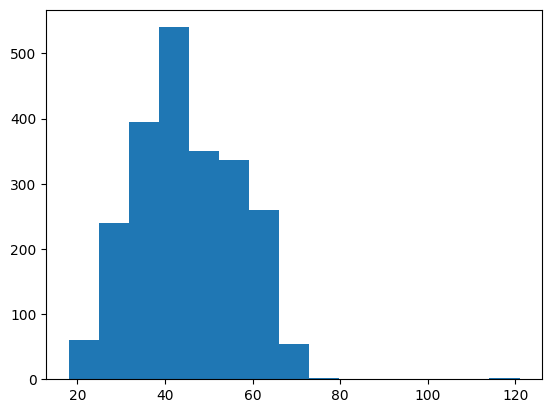

In [15]:
plt.plot()
plt.hist(df_eng['Age'], bins=15)

In [16]:
df_eng['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [17]:
df_eng['Enrollment_Days'] = (datetime.strptime('2014-08-01', '%Y-%m-%d') - df_eng['Dt_Customer']).dt.days

(array([ 74.,  97.,  88.,  97.,  87.,  85.,  77.,  78.,  96., 101.,  93.,
         93.,  87.,  88.,  91.,  84.,  93., 105.,  75.,  95.,  79.,  95.,
         81., 110.,  91.]),
 array([ 33.  ,  60.96,  88.92, 116.88, 144.84, 172.8 , 200.76, 228.72,
        256.68, 284.64, 312.6 , 340.56, 368.52, 396.48, 424.44, 452.4 ,
        480.36, 508.32, 536.28, 564.24, 592.2 , 620.16, 648.12, 676.08,
        704.04, 732.  ]),
 <BarContainer object of 25 artists>)

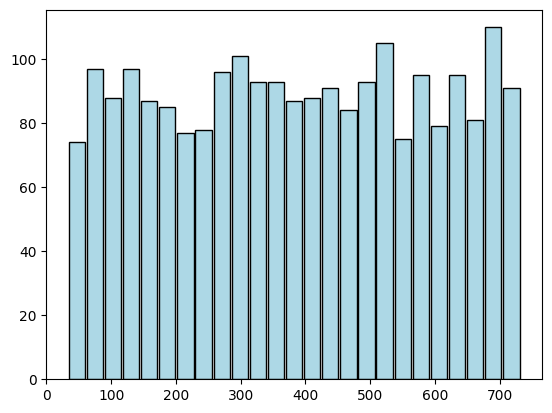

In [18]:
plt.plot()
plt.hist(df_eng['Enrollment_Days'], bins=25, color='lightblue',edgecolor='black', rwidth=0.90)

In [19]:
df_eng['Total_Spent'] = df['MntFishProducts'] + df['MntFruits'] + df['MntWines'] + df['MntSweetProducts'] + df['MntGoldProds'] + df['MntMeatProducts']

(array([731., 175., 127., 107., 115.,  75.,  68.,  79.,  84.,  91.,  86.,
         91.,  60.,  60.,  56.,  56.,  46.,  36.,  29.,  24.,  20.,   9.,
          7.,   3.,   5.]),
 array([   5. ,  105.8,  206.6,  307.4,  408.2,  509. ,  609.8,  710.6,
         811.4,  912.2, 1013. , 1113.8, 1214.6, 1315.4, 1416.2, 1517. ,
        1617.8, 1718.6, 1819.4, 1920.2, 2021. , 2121.8, 2222.6, 2323.4,
        2424.2, 2525. ]),
 <BarContainer object of 25 artists>)

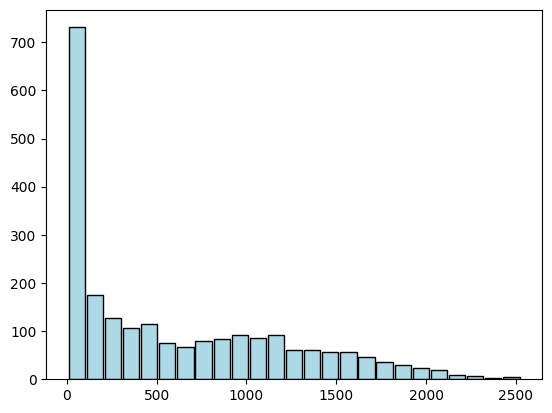

In [20]:
plt.plot()
plt.hist(df_eng['Total_Spent'], bins=25, color='lightblue',edgecolor='black', rwidth=0.90)

In [21]:
df_eng['Total_Acp'] = df['AcceptedCmp1'] +df['AcceptedCmp2'] +df['AcceptedCmp3'] +df['AcceptedCmp4'] +df['AcceptedCmp5']

(array([1777.,  325.,   83.,   55.]),
 array([0., 1., 2., 3., 4.]),
 <BarContainer object of 4 artists>)

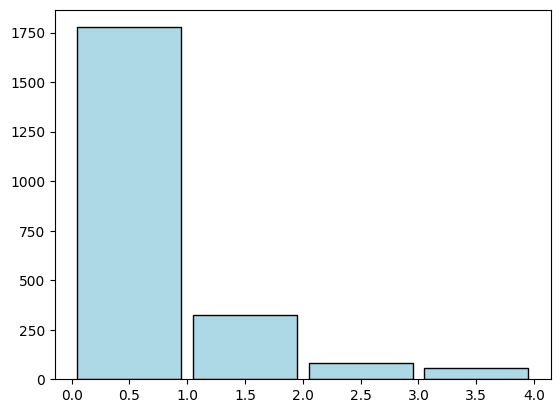

In [22]:
plt.plot()
plt.hist(df_eng['Total_Acp'], bins=4, color='lightblue',edgecolor='black', rwidth=0.90)

## Dirty Data Cleaning

1. Delete Z* columns
2. 위에서 변환한 피쳐들 제거
3. Delete Missing value (Income)

In [23]:
df_clean = df_eng.drop(['Z_CostContact','Z_Revenue'],axis=1)
df_clean = df_clean.drop(['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5'],axis=1)
df_clean = df_clean.drop(['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'],axis=1)
df_clean = df_clean.drop(['Dt_Customer','Year_Birth'],axis=1)

In [24]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   NumDealsPurchases    2240 non-null   int64  
 8   NumWebPurchases      2240 non-null   int64  
 9   NumCatalogPurchases  2240 non-null   int64  
 10  NumStorePurchases    2240 non-null   int64  
 11  NumWebVisitsMonth    2240 non-null   int64  
 12  Complain             2240 non-null   int64  
 13  Response             2240 non-null   int64  
 14  Age                  2240 non-null   int64  
 15  Enrollment_Days      2240 non-null   int64  
 16 

In [25]:
df_clean = df_clean.dropna(axis=0)

In [26]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Education            2216 non-null   str    
 2   Marital_Status       2216 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Recency              2216 non-null   int64  
 7   NumDealsPurchases    2216 non-null   int64  
 8   NumWebPurchases      2216 non-null   int64  
 9   NumCatalogPurchases  2216 non-null   int64  
 10  NumStorePurchases    2216 non-null   int64  
 11  NumWebVisitsMonth    2216 non-null   int64  
 12  Complain             2216 non-null   int64  
 13  Response             2216 non-null   int64  
 14  Age                  2216 non-null   int64  
 15  Enrollment_Days      2216 non-null   int64  
 16  Tota

## Data Inspecting

In [ ]:
corr_matrix = df_clean.corr(method='pearson', numeric_only=True)
print("--- 상관계수 행렬 ---")
print(corr_matrix)

# 3. 히트맵(Heatmap) 시각화
plt.figure(figsize=(20, 20))

# annot=True: 네모 칸 안에 숫자를 표시
# cmap='coolwarm': 양의 상관관계는 빨간색, 음의 상관관계는 파란색으로 표시
# vmin=-1, vmax=1: 색상 범위를 -1에서 1로 고정
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",       # 숫자가 겹치지 않게 소수점 둘째 자리까지만 표시
            cmap='coolwarm', # 파란색(음수) ~ 하얀색(0) ~ 빨간색(양수)
            vmin=-1,         # 최솟값은 무조건 -1
            vmax=1,          # 최댓값은 무조건 1
            linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=15)
plt.show()

I think Use Total_Acp, Total_Spent, Enrollment_Days, NumCatalogPurchases, (NumWebPurchases, Income) to classification

# Data Preprocessing


In [ ]:
model_features = ['Total_Acp', 'Total_Spent', 'Enrollment_Days', 'NumCatalogPurchases']
target = 'Response'

model_df = df_clean.loc[:, model_features + [target]].copy()
model_df['Total_Spent_log'] = np.log1p(model_df['Total_Spent'])
model_df = model_df.drop(columns=['Total_Spent'])

print(model_df.shape)
print(model_df[target].value_counts(normalize=True).rename('ratio'))


In [ ]:
print(model_df.head())


In [ ]:
features = ['Enrollment_Days', 'Total_Spent_log', 'NumCatalogPurchases', 'Total_Acp']
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i in range(2):
    for j in range(2):
        col_idx = i * 2 + j
        col_name = features[col_idx]
        ax[i][j].hist(model_df[col_name], bins=25, color='lightblue', edgecolor='black', rwidth=0.90)
        ax[i][j].set_title(f'{col_name} Histogram', fontsize=12)

plt.tight_layout()
plt.show()


Check NumCatalogPurchases > 8 is outlier


In [ ]:
catalog_outliers = model_df[model_df['NumCatalogPurchases'] > 8]
print(catalog_outliers[target].value_counts())
print(catalog_outliers.shape)


In [ ]:
# Keep rows where NumCatalogPurchases is 8 or lower.
model_df = model_df[model_df['NumCatalogPurchases'] <= 8].copy()

X = model_df.drop(columns=[target])
y = model_df[target]

print(X.shape, y.shape)
print(y.value_counts())


# Model Learning


## Baseline - KNN

In [80]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(3, 32, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}


In [82]:
grid_search = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_knn_model = grid_search.best_estimator_
print('Best parameters:', grid_search.best_params_)
print('Best CV F1:', grid_search.best_score_)


Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Best CV F1: 0.46827653130346497


In [83]:
y_pred = best_knn_model.predict(X_test)

print('Test accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test accuracy: 0.871331828442438
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       376
           1       0.61      0.42      0.50        67

    accuracy                           0.87       443
   macro avg       0.76      0.69      0.71       443
weighted avg       0.86      0.87      0.86       443



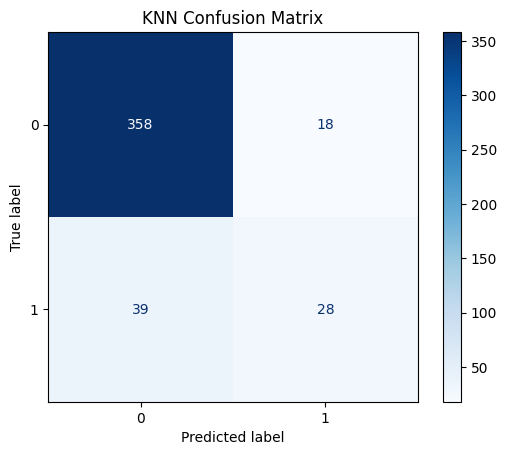

In [84]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn_model.classes_)
disp.plot(cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score
)

y_pred = best_knn_model.predict(X_test)
y_proba = best_knn_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC / Average Precision:", average_precision_score(y_test, y_proba))

print(classification_report(y_test, y_pred))


1을 찾는 문제 -> recall을 올려야한다.